# RDA GO

> Redundancy analysis genomic offset

The genomic offset based on Redundancy analysis [@Capblancq_2021]

> ⚠️ Documentation is not complete yet!.

In [ ]:
#| default_exp RDA

In [ ]:
#| hide
from fastcore.utils import *
from nbdev.showdoc import *
import numpy as np
import statsmodels.api as sm

An RDA model takes a hyperparameter $K$ as input, that corresponds to the maximum number of canonical axes to compute.  

In [ ]:
#| export
class RDA:
    "Redundancy analysis genomic offset statistic."
    def __init__(self, K: int):
        self._reg = None
        self._pca = None
        self.K = K
    def __str__(self):
        return f"Redundancy analysis model with K={self.K}"
    __repr__ = __str__

In order to use the model we have first to initialize it:  

In [ ]:
K = 1
model = RDA(K)

Then, we have to fit the model, that is ...

> ⚠️ Documentation is not complete yet!.

In [ ]:
#|export
@patch
def fit(self:RDA,
        Y: np.ndarray, # Allele frequency matrix (nxL)
        X: np.ndarray): # Environmental matrix (nxP)
    "Fits the RDA model. "
    n1, L = Y.shape
    n2, P = X.shape
    if n1 != n2: 
        raise ValueError("Dimensions of array don't match")
    X = sm.add_constant(X)
    model = sm.OLS(Y, X)
    self._reg = model.fit()
    self._pca = sm.PCA(self._reg.predict(X), ncomp=self.K, method="nipals")

The `fit()` method expects as input an genotype (or allele) matrix $\mathbf Y$ and an environmental matrix $\mathbf X$ with as many rows as individuals (or populations). For now, let us use the causal dataset we simulated in the previous section named [Simulations](simulation.html).  

In [ ]:
# If the package is intalled, the dataset 
# can be accessed with the commented code
#from genomic_offsets import datasets
#import importlib.resources 
# causal_dataset = np.load(importlib.resources.files(datasets).joinpath('causal.npz'))
causal_dataset = np.load("../genomic_offsets/datasets/causal.npz")

In [ ]:
# Read matrices
X, Xstar = causal_dataset["X"], causal_dataset["Xstar"]
Y = causal_dataset["Y"]
neglog_fitness = -np.log(causal_dataset["wstar"]+1e-5)
# Check dimensions
N, P = X.shape
assert Xstar.shape == (N, P)
assert Y.shape[0] == N

Let's split it into a train and test dataset: 

In [ ]:
rng = np.random.default_rng(1000) 
indices = rng.permutation(N)
training_idx, test_idx = indices[:60], indices[60:]
X_train, X_test = X[training_idx,:], X[test_idx,:]
Xstar_train, Xstar_test = Xstar[training_idx,:], Xstar[test_idx,:]
Y_train = Y[training_idx,:]
neglog_fitness_train, neglog_fitness_test =  neglog_fitness[training_idx], neglog_fitness[test_idx]

We can fit the RDA model to the training dataset. In order to do so, we first have to remove un unvariable sites: 

In [ ]:
print(f"Shape before: {Y_train.shape}")
Y_train = Y_train[:, Y_train.var(axis=0) > 0]
print(f"Shape after: {Y_train.shape}")

Shape before: (60, 219)
Shape after: (60, 204)


In [ ]:
model.fit(Y_train, X_train)

The RDA genomic offset metric measures the distance between the *projected* predicted (locally optimal) genotypes (or allele frequencies). As such, we can visualize the projected genotypes for different environmental matrices. 

> ⚠️ Documentation is not complete yet!. This example is not very good for example...

In [ ]:
#| export 
@patch
def predict(self:RDA,
        X: np.ndarray # Environmental matrix (nxP)
           )-> np.ndarray: # Predicted allele frequencies
    "Predicts the projected alleles for a given environmental matrix."
    X = sm.add_constant(X)
    return np.dot(self._reg.predict(X), self._pca.loadings)

The projected matrices have one row per individual (or population), and one column per canonical axis. Below, we can visualize how the model predicts that, under the altered environment should shift: 

In [ ]:
import matplotlib.pyplot as plt

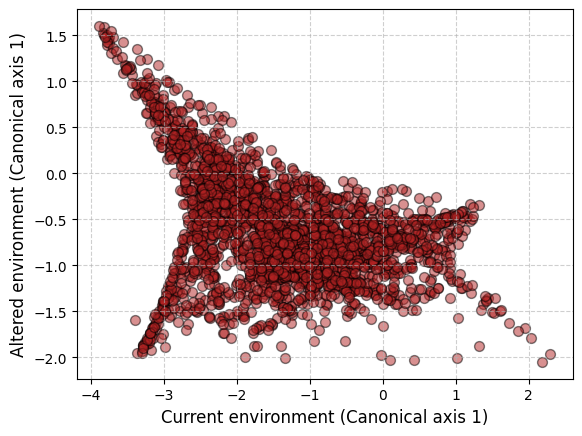

In [ ]:
proj_X, proj_Xstar = model.predict(X_test), model.predict(Xstar_test)
fig, ax = plt.subplots()
scatter = ax.scatter(proj_X, proj_Xstar, c='firebrick', edgecolor='k', alpha=0.5, s=50)
ax.set_xlabel('Current environment (Canonical axis 1)', fontsize=12)
ax.set_ylabel('Altered environment (Canonical axis 1)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()


Finally, we can predict the genomic offset under two different environments: 

In [ ]:
#| export 
@patch
def genomic_offset(self:RDA,
        X: np.ndarray, # Environmental matrix (nxP)
        Xstar: np.ndarray, # Altered environmental matrix (nxP)
           )-> np.ndarray: # A vector of genomic offsets (n)
    "Calculates the genomic offset statistic. " 
    if X.shape != Xstar.shape: 
        raise ValueError("Dimensions of array don't match")
    offset = np.zeros(X.shape[0])
    diff = self.predict(X) - self.predict(Xstar)
    weights = self._pca.eigenvals / np.sum(self._pca.eigenvals)
    L = self._reg.params.shape[1]
    for distance, w in zip(diff.T, weights):
        offset += distance**2*w/L
    return offset
    

As expected, the genomic offset is zero if both environmental matrixes are identical: 

In [ ]:
model.genomic_offset(X_train, X_train)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0.])

First, let's compute the (causal) training genomic offset with the RDA model and measure its association with the training negative logarithm of altered fitness:  

In [ ]:
from scipy.stats import pearsonr

In [ ]:
training_offset = model.genomic_offset(X_train, Xstar_train)
pearsonr(training_offset, neglog_fitness_train)

PearsonRResult(statistic=np.float64(0.308508920862633), pvalue=np.float64(0.016473662796124198))

Finally, let's compute the (still causal) test genomic offset (that is, a measure of decrease in fitness for all individuals we did not observe their genotypes and did not use to fit the model) 

In [ ]:
testing_offset = model.genomic_offset(X_test, Xstar_test)
testing_offset

array([6.10572576e-04, 3.29243642e-02, 1.24433415e-05, ...,
       2.05921675e-02, 3.33038419e-03, 3.66471351e-03])

In [ ]:
pearsonr(testing_offset, neglog_fitness_test)

PearsonRResult(statistic=np.float64(0.3288959943860878), pvalue=np.float64(2.5105495352866084e-70))

## Adjusting for population structure

Partial RDA is a special case in which we adjust for a set of additional explanatory variables (like PCA components to adjust for population structure. Let us denote the matrix of covariates we want to condition on $\mathbf W$, which has as many rows as individuals (or populations). First, we perform an RDA analysis of $\mathbf W$ on our response matrix $\mathbf Y$. Then, we perform an RDA analysis of $\mathbf X$ (our environmental variables) on the residuals of the first RDA (please, refer to @Capblancq_2021 for more details). 

As an example, let's perform a PCA over our genotype matrix, and use the first 3 components to adjust for population structure.

In [ ]:
import statsmodels.api as sm

In [ ]:
Y = Y[:, Y.var(axis=0) > 0]
pca = sm.PCA(Y, ncomp=3, method="nipals")
W = pca.scores
W.shape

(2808, 3)

As before, a partial RDA model takes a hyperparameter $K$ as input, that corresponds to the maximum number of canonical axes to compute.  

In [ ]:
#| export
class partial_RDA:
    "Redundancy analysis genomic offset statistic."
    def __init__(self, K: int):
        self._mod = None
        self._reg_X = None
        self._reg_residuals = None
        self._pca = None
        self.K = K
    def __str__(self):
        return f"Partial redundancy analysis model with K={self.K}"
    __repr__ = __str__

In order to use the model we have first to initialize it:  

In [ ]:
K = 1
model = partial_RDA(K)

Then, we have to fit the model, that is ...

> ⚠️ Documentation is not complete yet!.

In [ ]:
#|export
@patch
def fit(self:partial_RDA,
        Y: np.ndarray, # Allele frequency matrix (nxL)
        X: np.ndarray, # Environmental matrix (nxP)
        W: np.ndarray): # Covariate matrix (nxZ)
    "Fits the partial RDA model. "
    n1, L = Y.shape
    n2, P = X.shape
    n3, Z = W.shape
    if n1 != n2 or n1 != n3: 
        raise ValueError("Dimensions of array don't match")
    W = sm.add_constant(W)
    self._reg_X = sm.OLS(X, W).fit()
    residuals_Y = sm.OLS(Y, W).fit().resid.reshape(Y.shape)
    residuals_X = sm.add_constant(self._reg_X.resid.reshape(X.shape))
    self._reg_residuals = sm.OLS(residuals_Y,  residuals_X).fit()
    self._pca = sm.PCA(self._reg_residuals.predict(residuals_X), ncomp=self.K, method="nipals")

The `fit()` method expects as input an genotype (or allele) matrix $\mathbf Y$, an environmental matrix $\mathbf X$ with as many rows as individuals (or populations) and a matrix of covariates $\mathbf W$. As before, let us use the causal dataset we simulated in the previous section named [Simulations](simulation.html).  

In [ ]:
model.fit(Y, X, W)

As the regular RDA, the partial RDA genomic offset metric measures the distance between the *projected* predicted (locally optimal) genotypes (or allele frequencies). As such, we can visualize the projected genotypes for different environmental matrices and covariates. 

> ⚠️ Documentation is not complete yet!

In [ ]:
#| export 
@patch
def predict(self:partial_RDA,
        X: np.ndarray, # Environmental matrix (nxP)
        W: np.ndarray # Covariate matrix (nxZ)
           )-> np.ndarray: # Predicted allele frequencies
    "Predicts the projected alleles for a given environmental matrix."
    W = sm.add_constant(W)
    residuals_X = (X - self._reg_X.predict(W).reshape(X.shape))
    residuals_X = sm.add_constant(residuals_X)
    pred_residuals_Y = self._reg_residuals.predict(residuals_X)
    return np.dot(pred_residuals_Y, self._pca.loadings)

The projected matrices have one row per individual (or population), and one column per canonical axis. Below, we can visualize how the model predicts that under the altered environment should shift. Here, the covariates do not vary between both conditions. 


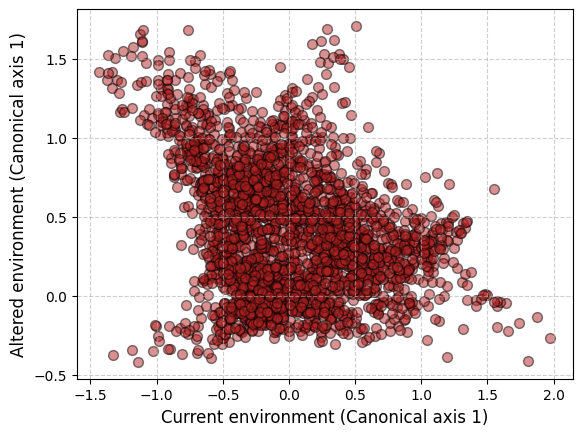

In [ ]:
proj_X, proj_Xstar = model.predict(X, W), model.predict(Xstar, W)
fig, ax = plt.subplots()
scatter = ax.scatter(proj_X, proj_Xstar, c='firebrick', edgecolor='k', alpha=0.5, s=50)
ax.set_xlabel('Current environment (Canonical axis 1)', fontsize=12)
ax.set_ylabel('Altered environment (Canonical axis 1)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()


Finally, we can predict the genomic offset under two different environments: 

In [ ]:
#| export 
@patch
def genomic_offset(self:partial_RDA,
        X: np.ndarray, # Environmental matrix (nxP)
        Xstar: np.ndarray, # Altered environmental matrix (nxP)
        W: np.ndarray # Covariate matrix (nxZ)
           )-> np.ndarray: # A vector of genomic offsets (n)
    "Calculates the genomic offset statistic. " 
    if X.shape != Xstar.shape: 
        raise ValueError("Dimensions of array don't match")
    if X.shape[0] != W.shape[0]: 
        raise ValueError("Dimensions of array don't match")
    offset = np.zeros(X.shape[0])
    diff = self.predict(X, W) - self.predict(Xstar, W)
    weights = self._pca.eigenvals / np.sum(self._pca.eigenvals)
    L = self._reg_residuals.params.shape[1]
    for distance, w in zip(diff.T, weights):
        offset += distance**2*w/L
    return offset

As expected, the genomic offset is zero if both environmental matrixes are identical: 

In [ ]:
model.genomic_offset(X, X, W)

array([0., 0., 0., ..., 0., 0., 0.])

Let's compute the correlation between the partial RDA genomic offset of the whole population (fitted with the entire population) and the negative logarithm of altered fitness. Please, notice that, if selecting the covariates to adjust correctly, we expect the performance to improve (but it does not here, as we are using the causal dataset with only QTLs, where population structure should play a minor role). 

In [ ]:
offset = model.genomic_offset(X, Xstar, W)
pearsonr(offset, neglog_fitness)

PearsonRResult(statistic=np.float64(0.32868269558201324), pvalue=np.float64(9.991476444135416e-72))

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()